# Сравнение обычной модели и наивной INT8-квантизации

Что происходит:

1. беру готовый датасет FashionMNIST
2. обучаю простую модель
3. считаю loss на трейне и валидации
4. смотрю на `model.parameters()`
5. пишу класс `NaiveQuantize`
6. прохожу по параметрам модели и наивно "квантизую" веса в int8
7. считаю точность через `model_fp16.forward(val_set)` и `model_quant.forward(val_set)`
8. сравниваю результаты
9. строю графики


>Снизу еще докинут блок кода с чата гпт, он сказал это настоящая квантизация `LLM.int8()` через `bitsandbytes`.


In [ ]:
%pip install torch torchvision matplotlib pandas
#%pip install transformers accelerate bitsandbytes  # для последенго блока


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ===== Импорты =====

import random
from copy import deepcopy

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST


# ===== Фиксируем случайность =====
# Это нужно, чтобы результаты были более воспроизводимыми
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


# ===== Выбираем устройство =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda


In [ ]:
# ===== Базовые настройки =====
# Количество эпох, размер батча и шаг обучения

batch_size = 256
epochs = 5
learning_rate = 1e-3

# Размеры train/val.
train_size = 48000
val_size = 12000


print("batch_size =", batch_size)
print("epochs =", epochs)
print("learning_rate =", learning_rate)


batch_size = 256
epochs = 5
learning_rate = 0.001


In [ ]:
# ===== Загружаем датасет FashionMNIST =====
# Это готовый датасет одежды из 10 классов
# Он автоматически скачивается в папку ./data при первом запуске

full_train_dataset = FashionMNIST(
    root="./data",
    train=True,
    download=True,
)

# Внутри датасета изображения лежат как uint8 в диапазоне 0..255
# Переводим их в float и нормируем в диапазон 0..1
# По сути просто масштабируем
all_x = full_train_dataset.data.float().unsqueeze(1) / 255.0
all_y = full_train_dataset.targets.long()

print("all_x shape =", all_x.shape)  
print("all_y shape =", all_y.shape)  
print("число классов =", len(torch.unique(all_y)))


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.87MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 807kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 9.28MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

all_x shape = torch.Size([60000, 1, 28, 28])
all_y shape = torch.Size([60000])
число классов = 10


In [ ]:
# ===== Делим данные на train и validation =====
# Чтобы разбиение было случайным, перемешиваем индексы, подсмотрел в инете

generator = torch.Generator().manual_seed(seed)
indices = torch.randperm(len(all_x), generator=generator)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]

x_train = all_x[train_idx]
y_train = all_y[train_idx]

x_val = all_x[val_idx]
y_val = all_y[val_idx]

print("x_train shape =", x_train.shape)
print("y_train shape =", y_train.shape)
print("x_val shape =", x_val.shape)
print("y_val shape =", y_val.shape)


x_train shape = torch.Size([48000, 1, 28, 28])
y_train shape = torch.Size([48000])
x_val shape = torch.Size([12000, 1, 28, 28])
y_val shape = torch.Size([12000])


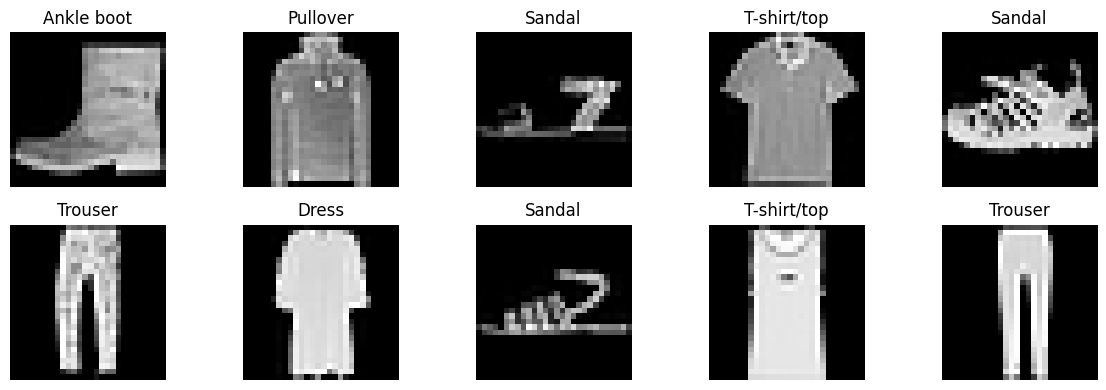

In [ ]:
# ===== Смотрим несколько примеров из датасета =====
# Посмотрим что с данными все норм

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i, 0], cmap="gray")
    plt.title(class_names[y_train[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# ===== Создаём DataLoaderы =====
# Они нужны для обучения модели батчами

train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("train batches =", len(train_loader))
print("val batches =", len(val_loader))


train batches = 188
val batches = 47


In [ ]:
# ===== Определяем простую модель =====
# Это МЛП, 
# 1) картинка 28x28 разворачивается в вектор длины 784
# 2) два скрытых слоя
# 3) выход на 10 классов

class SimpleMLP(nn.Module):
    def __init__(self, in_features=28 * 28, hidden_dim=256, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), # Переводим в вектор
            nn.Linear(in_features, hidden_dim), # Первый слой берёт 784 вектор и преобразует их в 256 новых чисел
            nn.ReLU(), # Нелинейность чтобы лучше училось
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # Здесь просто прогоняем вход через всю сеть
        return self.net(x)


# Создаём модель, функцию потерь и оптимизатор
model = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(model)


SimpleMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
# ===== Смотрим model.parameters() =====
# Смотрим все веса модели - их размер, тип и сколько чисел в каждом
# Вывод - номер параметра, форма, dtype и число элементов

for idx, param in enumerate(model.parameters()):
    print(
        f"parameter #{idx:02d} | shape = {tuple(param.shape)} | "
        f"dtype = {param.dtype} | numel = {param.numel()}"
    )


parameter #00 | shape = (256, 784) | dtype = torch.float32 | numel = 200704
parameter #01 | shape = (256,) | dtype = torch.float32 | numel = 256
parameter #02 | shape = (256, 256) | dtype = torch.float32 | numel = 65536
parameter #03 | shape = (256,) | dtype = torch.float32 | numel = 256
parameter #04 | shape = (10, 256) | dtype = torch.float32 | numel = 2560
parameter #05 | shape = (10,) | dtype = torch.float32 | numel = 10


In [ ]:
# ===== Функции для обучения и оценки =====
# train_one_epoch - одна эпоха обучения
# evaluate - оценк на валидации

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    # Переводим модель в режим обучения
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_items = 0

    for x_batch, y_batch in dataloader:
        # Переносим батч на нужное устройство
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Обнуляем старые градиенты
        optimizer.zero_grad()

        # Считаем logits модели
        logits = model(x_batch)

        # Считаем loss.
        loss = criterion(logits, y_batch)

        # Считаем градиенты
        loss.backward()

        # Делаем шаг оптимизации
        optimizer.step()

        # Накапливаем loss
        total_loss += loss.item()

        # Считаем количество правильных ответов
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total_items += y_batch.size(0)

    # Средний loss за эпоху
    avg_loss = total_loss / len(dataloader)

    # Средняя accuracy за эпоху
    avg_acc = total_correct / total_items

    return avg_loss, avg_acc


@torch.no_grad() # Без вычисления градиентов
def evaluate(model, dataloader, criterion, device):
    # Переводим модель в режим оценки
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_items = 0

    for x_batch, y_batch in dataloader:
        # Переносим батч на нужное устройство
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Считаем logits без градиентов
        logits = model(x_batch)

        # Считаем loss
        loss = criterion(logits, y_batch)

        # Накапливаем loss
        total_loss += loss.item()

        # Считаем правильные ответы.
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total_items += y_batch.size(0)

    avg_loss = total_loss / len(dataloader)
    avg_acc = total_correct / total_items

    return avg_loss, avg_acc


In [ ]:
# ===== Обучаем модель и сохраняем историю =====
# Нужны train loss и val loss

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

history_df = pd.DataFrame(history)
history_df


Epoch 01 | train_loss=0.6658 | val_loss=0.4651 | train_acc=0.7696 | val_acc=0.8408
Epoch 02 | train_loss=0.4272 | val_loss=0.4295 | train_acc=0.8471 | val_acc=0.8464
Epoch 03 | train_loss=0.3729 | val_loss=0.3673 | train_acc=0.8653 | val_acc=0.8694
Epoch 04 | train_loss=0.3431 | val_loss=0.3824 | train_acc=0.8754 | val_acc=0.8637
Epoch 05 | train_loss=0.3205 | val_loss=0.3506 | train_acc=0.8820 | val_acc=0.8740


,epoch,train_loss,val_loss,train_acc,val_acc
0,1,0.665774,0.465082,0.769604,0.840833
1,2,0.427192,0.429466,0.847146,0.846417
2,3,0.372855,0.367304,0.865333,0.869417
3,4,0.343100,0.382443,0.875354,0.863667
4,5,0.320487,0.350566,0.881958,0.874000


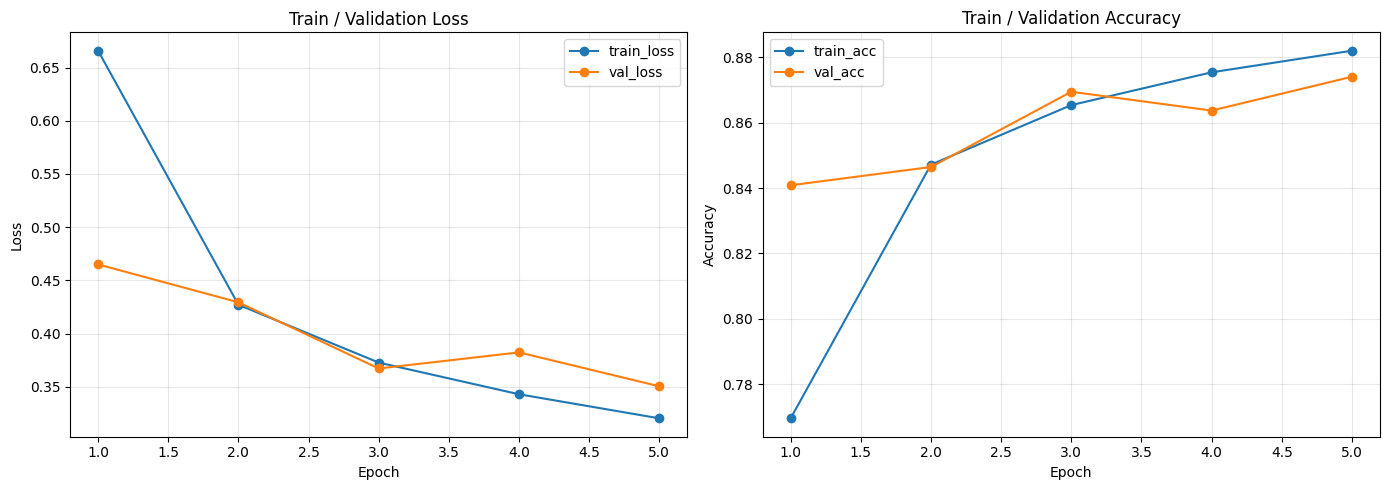

In [ ]:
# ===== Строим графики обучения =====
# Первый график: loss на train и validation
# Второй график: accuracy на train и validation

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train_acc")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Validation Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


## Наивная INT8-квантизация


Идея:
- копируем модель;
- проходим по её параметрам;
- для каждого весового тензора находим `scale`;
- переводим значения в диапазон int8;
- потом обратно восстанавливаем значения в float;
- записываем восстановленные веса в копию модели.

Это **не настоящий bitsandbytes `LLM.int8()`**, а именно **наивная учебная квантизация**.


In [ ]:
# ===== Дописал по шаблону класс =====

class NaiveQuantize:
    def __init__(self):
        
        self.zero_point = None
        self.scale = None

        # Дополнительно сейвим статистику по слоям для графиков
        self.layer_stats = []

    def quantize_model(self, model) -> torch.nn.Module:
        # Делаем копию модели, чтобы не портить исходную
        model_copy = deepcopy(model).eval()

        # Очищаем старую статистику
        self.layer_stats = []

        for layer_idx, layer in enumerate(model_copy.parameters()):

            # Если параметр не float, пропускаем его
            if not layer.data.is_floating_point():
                continue

            # Берём текущие веса
            weight = layer.data

            # Находим максимальное по модулю значение
            max_abs = weight.abs().max().item()

            # Если весь тензор нулевой, scale ставим 1.0, чтобы не делить на ноль
            if max_abs == 0:
                scale = 1.0
            else:
                # Симметричная квантизация в диапазон [-128, 127]
                scale = max_abs / 127.0

            # Для простоты берём zero_point = 0
            zero_point = 0

            # Переводим float-веса в int8
            q_weight = torch.clamp(torch.round(weight / scale), -128, 127).to(torch.int8)

            # Возвращаем их обратно в float
            # Это нужно, потому что обычные nn.Linear ожидают float-веса
            restored_weight = (q_weight.float() - zero_point) * scale
            restored_weight = restored_weight.to(weight.dtype)

            # Считаем среднеквадратичную ошибку между исходным и восстановленным весом
            mse = torch.mean((weight.float() - restored_weight.float()) ** 2).item()

            # Записываем восстановленные веса обратно в слой
            layer.data.copy_(restored_weight)

            # Сохраняем scale и zero_point последнего обработанного слоя
            self.scale = scale
            self.zero_point = zero_point

            # Сохраняем статистику для таблицы и графика
            self.layer_stats.append({
                "layer_index": layer_idx,
                "shape": tuple(layer.shape),
                "scale": scale,
                "zero_point": zero_point,
                "mse": mse,
                "numel": layer.numel()
            })

        return model_copy


In [ ]:
# ===== Готовим baseline-модель для сравнения =====
# У нас должна быть model_fp16
# Если CUDA, переводим копию модели в half()
# Если не CUDA - float32, потому что на CPU fp16 часто неудобен по словам нейронки

model_fp16 = deepcopy(model).eval().to(device)

if device.type == "cuda":
    model_fp16 = model_fp16.half()
    print("Baseline-модель переведена в FP16.")
else:
    print("CUDA нет, поэтому baseline остаётся в FP32, но переменную всё равно называем model_fp16 для единообразия.")


Baseline-модель переведена в FP16.


In [ ]:
# ===== Делаем наивную INT8-квантизацию =====
# Здесь создаём объект квантователя и получаем квантизованную модель(какие умные слова)

quantizer = NaiveQuantize()
model_quant = quantizer.quantize_model(model_fp16).to(device).eval()

# Смотрим таблицу по слоям после квантизации.
quant_stats_df = pd.DataFrame(quantizer.layer_stats)
quant_stats_df


,layer_index,shape,scale,zero_point,mse,numel
0,0,"(256, 784)",0.003068,0,7.854701e-07,200704
1,1,"(256,)",0.001865,0,2.735314e-07,256
2,2,"(256, 256)",0.003137,0,8.192955e-07,65536
3,3,"(256,)",0.001487,0,1.845472e-07,256
4,4,"(10, 256)",0.003487,0,1.011301e-06,2560
5,5,"(10,)",0.000826,0,7.552008e-08,10


In [ ]:
# ===== Готовим validation set для прямого вызова forward =====
# Мы хотим тупо посчитать качество через:
# model_fp16.forward(val_set)
# model_quant.forward(val_set)

# Переносим validation-набор на нужное устройство
val_x_device = x_val.to(device)
val_y_device = y_val.to(device)

# Если baseline в half и мы на CUDA, вход тоже переводим в half
if device.type == "cuda":
    val_x_for_fp16 = val_x_device.half()
else:
    val_x_for_fp16 = val_x_device

# Для quantized-модели подаём вход того же типа, что и для baseline
val_x_for_quant = val_x_for_fp16

print("val_x_for_fp16 shape =", val_x_for_fp16.shape)
print("val_y_device shape =", val_y_device.shape)


val_x_for_fp16 shape = torch.Size([12000, 1, 28, 28])
val_y_device shape = torch.Size([12000])


In [ ]:
# ===== Считаем точность и loss через прямой forward =====

@torch.no_grad()
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    acc = (preds == labels).float().mean().item()
    return acc

with torch.no_grad():
    # Прямой вызов forward для baseline-модели
    logits_fp16 = model_fp16.forward(val_x_for_fp16)

    # Прямой вызов forward для квантизованной модели
    logits_quant = model_quant.forward(val_x_for_quant)

# Для функции потерь CrossEntropyLoss лучше считать loss в float32
loss_fp16 = criterion(logits_fp16.float(), val_y_device).item()
loss_quant = criterion(logits_quant.float(), val_y_device).item()

acc_fp16 = accuracy_from_logits(logits_fp16, val_y_device)
acc_quant = accuracy_from_logits(logits_quant, val_y_device)

print("Baseline loss  =", round(loss_fp16, 6))
print("Baseline acc   =", round(acc_fp16, 6))
print("Quantized loss =", round(loss_quant, 6))
print("Quantized acc  =", round(acc_quant, 6))


Baseline loss  = 0.350535
Baseline acc   = 0.874
Quantized loss = 0.350446
Quantized acc  = 0.873667


In [18]:
# ===== Сравниваем модели в одной таблице =====

comparison_df = pd.DataFrame([
    {
        "model": "model_fp16" if device.type == "cuda" else "baseline_fp32_cpu",
        "val_loss_from_forward": loss_fp16,
        "val_acc_from_forward": acc_fp16,
    },
    {
        "model": "model_quant",
        "val_loss_from_forward": loss_quant,
        "val_acc_from_forward": acc_quant,
    }
])

comparison_df["acc_delta_vs_baseline"] = comparison_df["val_acc_from_forward"] - comparison_df.loc[0, "val_acc_from_forward"]
comparison_df["loss_delta_vs_baseline"] = comparison_df["val_loss_from_forward"] - comparison_df.loc[0, "val_loss_from_forward"]

comparison_df


,model,val_loss_from_forward,val_acc_from_forward,acc_delta_vs_baseline,loss_delta_vs_baseline
0,model_fp16,0.350535,0.874000,0.000000,0.000000
1,model_quant,0.350446,0.873667,-0.000333,-0.000089


acc_delta_vs_baseline Это насколько изменилась accuracy по сравнению с baseline
у первой строки 0.000000, потому что baseline сравнивается сам с собой
у второй строки -0.000333, значит quantized модель дала accuracy чуть ниже

loss_delta_vs_baselin Это насколько изменился loss по сравнению с baseline
loss_delta_vs_baseline = loss_текущей_модели - loss_baseline

Поэтому:
у baseline снова 0.000000
у quantized -0.000089

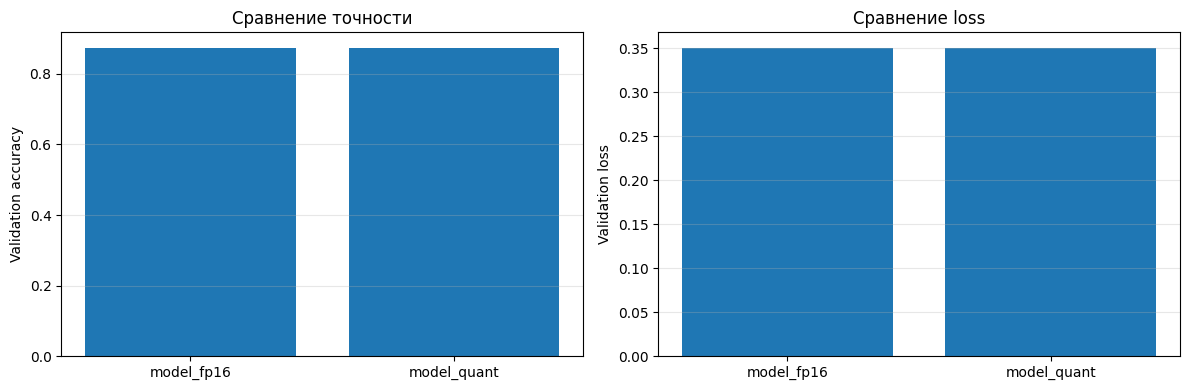

In [ ]:
# ===== График сравнения accuracy и loss =====
# Делаем два столбчатых графика: отдельно по accuracy и отдельно по loss

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(comparison_df["model"], comparison_df["val_acc_from_forward"])
plt.ylabel("Validation accuracy")
plt.title("Сравнение точности")
plt.grid(axis="y", alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(comparison_df["model"], comparison_df["val_loss_from_forward"])
plt.ylabel("Validation loss")
plt.title("Сравнение loss")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


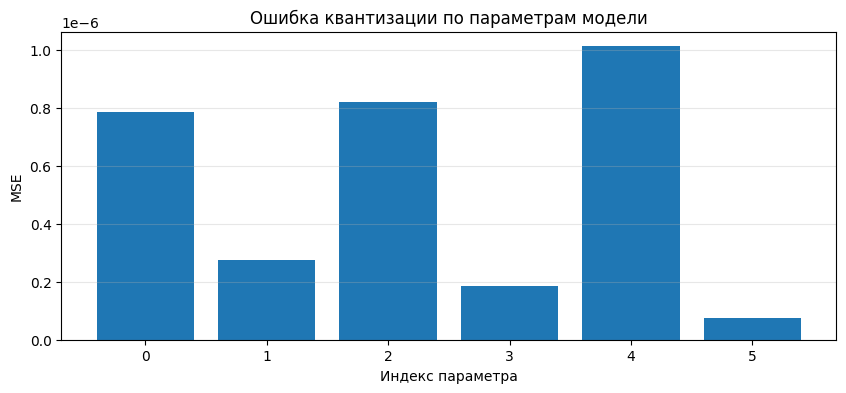

In [ ]:
# ===== График ошибки квантизации по слоям =====
# Смотрим, в каких параметрах ошибка после квантизации была больше

plt.figure(figsize=(10, 4))
plt.bar(quant_stats_df["layer_index"].astype(str), quant_stats_df["mse"])
plt.xlabel("Индекс параметра")
plt.ylabel("MSE")
plt.title("Ошибка квантизации по параметрам модели")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Пример настоящего `LLM.int8()`

Этот блок **фулл сгенерирован**  
Он просто показывает, как выглядит реальный `LLM.int8()` в экосистеме Hugging Face + bitsandbytes.



In [ ]:
# ===== Опциональный блок с реальным LLM.int8() =====
# Он показывает как обычно загружают модель в 8 бит.

RUN_LLM_INT8_DEMO = True

if RUN_LLM_INT8_DEMO:
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    #Берём очень маленькую модель, чтобы пример был полегче.
    model_id = "sshleifer/tiny-gpt2"

    #Говорим, что хотим загрузить модель в 8 бит.
    quantization_config = BitsAndBytesConfig(load_in_8bit=True)

    #Загружаем токенизатор.
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    #Загружаем модель в 8 бит.
    llm_int8_model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=quantization_config,
        device_map="auto"
    )

    #Делаем маленький тестовый prompt.
    prompt = "Machine learning is"
    inputs = tokenizer(prompt, return_tensors="pt")

    #Переносим входы на устройство модели.
    inputs = {k: v.to(llm_int8_model.device) for k, v in inputs.items()}

    #Генерируем продолжение.
    with torch.no_grad():
        output_ids = llm_int8_model.generate(**inputs, max_new_tokens=20)

    print(tokenizer.decode(output_ids[0], skip_special_tokens=True))

else:
    print("Блок выключен. Если захотите посмотреть пример настоящего LLM.int8(), поставьте RUN_LLM_INT8_DEMO = True.")


c:\Users\Sena\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Sena\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sena\.cache\huggingface\hub\models--sshleifer--tiny-gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an adminis

Machine learning is factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors
